### Classificação de lesões usando imagens segmentadas

Este notebook adapta a CNN de classificação para utilizar as máscaras do dataset como etapa de pré-processamento. As máscaras são aplicadas às imagens originais para destacar a região da lesão.

In [5]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import keras

from matplotlib import pyplot as plt
from keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from imblearn.over_sampling import SMOTE

In [6]:
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

In [7]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks"
CSV_PATH = "../data/GroundTruth.csv"
MASKS_CSV_PATH = "../data/GroundTruth_masks.csv"

In [8]:
metadata = pd.read_csv(CSV_PATH)

if "mask" not in metadata.columns:
    metadata.insert(1, "mask", metadata["image"].astype(str) + "_segmentation")

metadata.to_csv(MASKS_CSV_PATH, index=False)

print(metadata.head())
print(metadata.info())
print(f"Arquivo com máscaras salvo em: {MASKS_CSV_PATH}")

          image                       mask  MEL   NV  BCC  AKIEC  BKL   DF  \
0  ISIC_0024306  ISIC_0024306_segmentation  0.0  1.0  0.0    0.0  0.0  0.0   
1  ISIC_0024307  ISIC_0024307_segmentation  0.0  1.0  0.0    0.0  0.0  0.0   
2  ISIC_0024308  ISIC_0024308_segmentation  0.0  1.0  0.0    0.0  0.0  0.0   
3  ISIC_0024309  ISIC_0024309_segmentation  0.0  1.0  0.0    0.0  0.0  0.0   
4  ISIC_0024310  ISIC_0024310_segmentation  1.0  0.0  0.0    0.0  0.0  0.0   

   VASC  
0   0.0  
1   0.0  
2   0.0  
3   0.0  
4   0.0  
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   mask    10015 non-null  str    
 2   MEL     10015 non-null  float64
 3   NV      10015 non-null  float64
 4   BCC     10015 non-null  float64
 5   AKIEC   10015 non-null  float64
 6   BKL     10015 non-null  float64
 7   DF      10015 non-null  float64
 8  

#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [9]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS E USO DAS MÁSCARAS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e mantém apenas os registros que possuem imagem original e máscara correspondente.

Como o objetivo é classificar as lesões em sete classes a partir das imagens segmentadas, a máscara é utilizada como pré-processamento para destacar a região da lesão. O rótulo do modelo continua sendo a classe diagnóstica da imagem: `MEL`, `NV`, `BCC`, `AKIEC`, `BKL`, `DF` ou `VASC`.

Esse formato é mantido como classificação multiclasse com `SparseCategoricalCrossentropy`.

In [10]:
def find_file(directory, base_name, extensions):
    for extension in extensions:
        path = os.path.join(directory, base_name + extension)
        if os.path.exists(path):
            return path
    return None


def prepare_metadata_with_paths(images_dir, masks_dir, metadata, class_code):
    rows = []

    for _, row in metadata.iterrows():
        image_name = str(row["image"])
        mask_name = str(row["mask"])

        image_path = find_file(images_dir, image_name, [".jpg", ".jpeg", ".png"])
        mask_path = find_file(masks_dir, mask_name, [".png", ".jpg", ".jpeg"])

        if image_path is None or mask_path is None:
            continue

        class_label = row[classes].idxmax()
        coded_label = class_code[class_label]

        rows.append({
            "image": image_name,
            "mask": mask_name,
            "image_path": image_path,
            "mask_path": mask_path,
            "label": coded_label,
            "class_name": class_label
        })

    prepared_df = pd.DataFrame(rows)

    return prepared_df


prepared_metadata = prepare_metadata_with_paths(
    IMAGES_DIR,
    MASKS_DIR,
    metadata,
    class_code
)

print(prepared_metadata.head())
print(prepared_metadata.info())
print("Quantidade de pares imagem-máscara encontrados:", len(prepared_metadata))

          image                       mask                       image_path  \
0  ISIC_0024306  ISIC_0024306_segmentation  ../data/images/ISIC_0024306.jpg   
1  ISIC_0024307  ISIC_0024307_segmentation  ../data/images/ISIC_0024307.jpg   
2  ISIC_0024308  ISIC_0024308_segmentation  ../data/images/ISIC_0024308.jpg   
3  ISIC_0024309  ISIC_0024309_segmentation  ../data/images/ISIC_0024309.jpg   
4  ISIC_0024310  ISIC_0024310_segmentation  ../data/images/ISIC_0024310.jpg   

                                     mask_path  label class_name  
0  ../data/masks/ISIC_0024306_segmentation.png      1         NV  
1  ../data/masks/ISIC_0024307_segmentation.png      1         NV  
2  ../data/masks/ISIC_0024308_segmentation.png      1         NV  
3  ../data/masks/ISIC_0024309_segmentation.png      1         NV  
4  ../data/masks/ISIC_0024310_segmentation.png      0        MEL  
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 6 columns):
 #   Column      Non-Null 

### CRIAÇÃO DO DATASET COM IMAGENS SEGMENTADAS

O dataset é criado carregando a imagem original e a máscara correspondente. Em seguida, a máscara é binarizada e multiplicada pela imagem original, gerando uma imagem segmentada.

Assim, a entrada da CNN passa a ser a imagem com a região da lesão destacada, mas a saída continua sendo uma das sete classes diagnósticas.

In [11]:
def load_segmented_image(image_path, mask_path, image_size):
    image = keras.utils.load_img(
        image_path,
        target_size=image_size,
        color_mode="rgb"
    )
    image = keras.utils.img_to_array(image).astype("float32")

    mask = keras.utils.load_img(
        mask_path,
        target_size=image_size,
        color_mode="grayscale"
    )
    mask = keras.utils.img_to_array(mask).astype("float32") / 255.0
    mask = (mask > 0.5).astype("float32")

    segmented_image = image * mask

    return segmented_image


X = []
y = []

for _, row in prepared_metadata.iterrows():
    segmented_image = load_segmented_image(
        row["image_path"],
        row["mask_path"],
        IMG_SIZE
    )

    X.append(segmented_image)
    y.append(row["label"])

X = np.array(X, dtype="float32")
y = np.array(y, dtype="int32")

dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(buffer_size=len(y), seed=42)

print("Formato das imagens segmentadas:", X.shape)
print("Formato dos rótulos:", y.shape)
print("Distribuição geral das classes:")
print(Counter(y))

Formato das imagens segmentadas: (10015, 128, 128, 3)
Formato dos rótulos: (10015,)
Distribuição geral das classes:
Counter({np.int32(1): 6705, np.int32(0): 1113, np.int32(4): 1099, np.int32(2): 514, np.int32(3): 327, np.int32(6): 142, np.int32(5): 115})


In [12]:
train_ds, test_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.8,
    shuffle=True,
    seed=42
)

### BALANCEAMENTO COM SMOTE E DATA AUGMENTATION

Após a criação das imagens segmentadas, o conjunto foi dividido em treino e teste. O SMOTE foi aplicado somente ao conjunto de treino, com o objetivo de balancear a quantidade de amostras entre as sete classes.

Em seguida, o conjunto de treino balanceado foi convertido novamente para `tf.data.Dataset`, embaralhado, dividido em batches e submetido ao Data Augmentation durante o treinamento.

O conjunto de teste não recebe SMOTE nem Data Augmentation, pois deve representar dados não vistos pelo modelo.

In [13]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels


In [14]:

def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for image, label in ds:
        images_list.append(image.numpy().astype("float32"))
        labels_list.append(label.numpy())

    X = np.stack(images_list)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

X_train, y_train = dataset_to_numpy(train_ds)

In [15]:
print("Distribuição original do treino:")
print(Counter(y_train))

Distribuição original do treino:
Counter({np.int32(1): 5332, np.int32(0): 902, np.int32(4): 879, np.int32(2): 416, np.int32(3): 279, np.int32(6): 115, np.int32(5): 89})


In [16]:
original_train_label_counts = pd.Series(y_train).value_counts().sort_index()
original_train_label_counts.index = [class_name[i] for i in original_train_label_counts.index]

n_samples, height, width, channels = X_train.shape

X_train_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_smote_flat, y_train_smote = smote.fit_resample(
    X_train_flat,
    y_train
)

X_train_smote = X_train_smote_flat.reshape(-1, height, width, channels)
X_train_smote = np.clip(X_train_smote, 0, 255).astype("float32")
y_train_smote = y_train_smote.astype("int32")

In [17]:
print("\nDistribuição do treino após SMOTE:")
print(Counter(y_train_smote))


Distribuição do treino após SMOTE:
Counter({np.int32(1): 5332, np.int32(3): 5332, np.int32(4): 5332, np.int32(2): 5332, np.int32(5): 5332, np.int32(0): 5332, np.int32(6): 5332})


In [18]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_smote, y_train_smote))

train_ds = train_ds.shuffle(
    buffer_size=len(y_train_smote),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

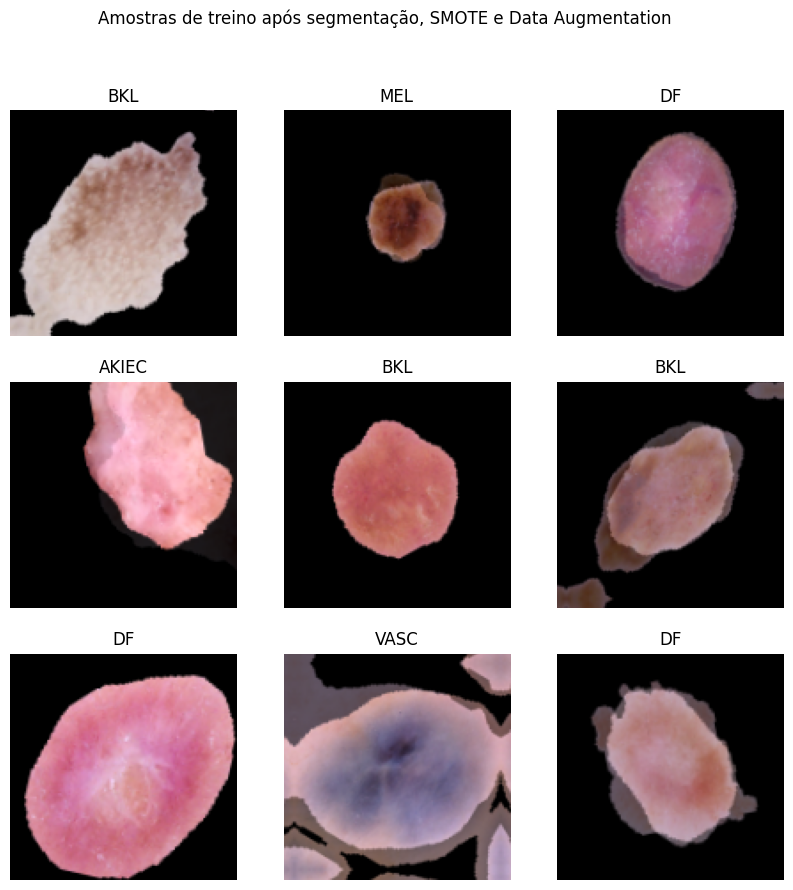

In [19]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.suptitle("Amostras de treino após segmentação, SMOTE e Data Augmentation")
plt.show()

Quantidade de imagens no conjunto de treino após SMOTE: 37324


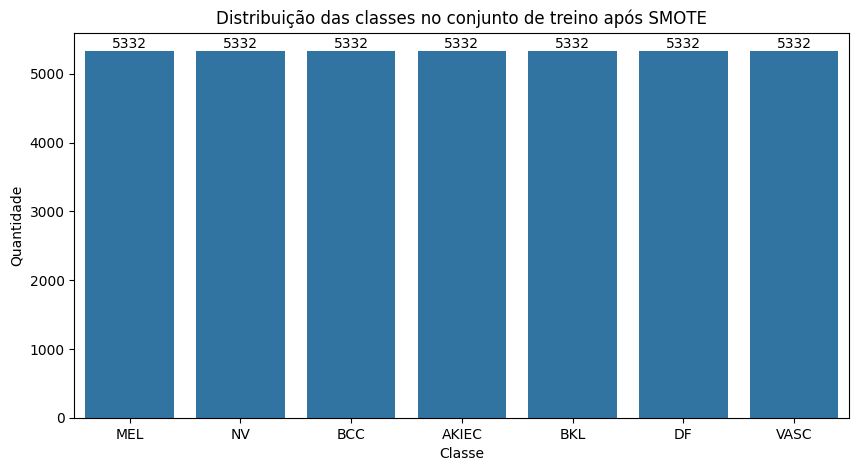

MEL      5332.0
NV       5332.0
BCC      5332.0
AKIEC    5332.0
BKL      5332.0
DF       5332.0
VASC     5332.0
dtype: object


In [20]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)

print("Quantidade de imagens no conjunto de treino após SMOTE:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino após SMOTE")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [21]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(classes))
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,951 (980.28 KB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [23]:
print("Distribuição final usada no treinamento:")
print(label_counts)

Distribuição final usada no treinamento:
MEL      5332.0
NV       5332.0
BCC      5332.0
AKIEC    5332.0
BKL      5332.0
DF       5332.0
VASC     5332.0
dtype: object


In [24]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [25]:
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Epoch 1/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 231s 197ms/step - accuracy: 0.5095 - loss: 1.4056 - val_accuracy: 0.6930 - val_loss: 1.2058
Epoch 2/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 301s 258ms/step - accuracy: 0.5988 - loss: 1.1635 - val_accuracy: 0.7029 - val_loss: 1.1700
Epoch 3/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 316s 271ms/step - accuracy: 0.6442 - loss: 1.0515 - val_accuracy: 0.7224 - val_loss: 0.9214
Epoch 4/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 327s 280ms/step - accuracy: 0.6846 - loss: 0.9547 - val_accuracy: 0.7224 - val_loss: 0.8584
Epoch 5/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 344s 294ms/step - accuracy: 0.7093 - loss: 0.8844 - val_accuracy: 0.6985 - val_loss: 0.9529
Epoch 6/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 340s 291ms/step - accuracy: 0.7325 - loss: 0.8281 - val_accuracy: 0.6735 - val_loss: 1.0012
Epoch 7/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 308s 264ms/step - accuracy: 0.7461 - loss: 0.7923 - val_accuracy: 0.6840 - val_loss: 0.9758
Epoch 8/200
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 279s 239ms/s

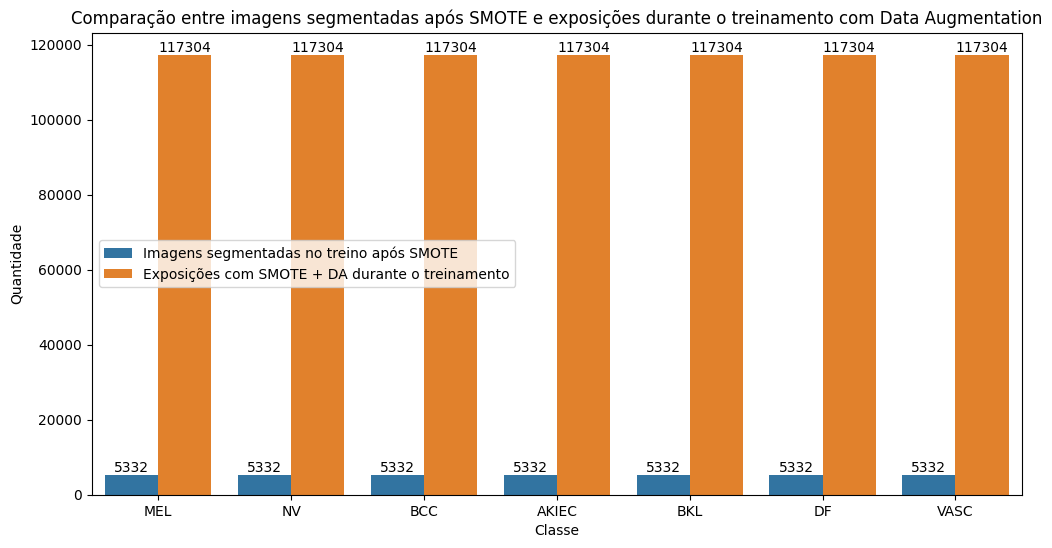

In [26]:
epochs = len(history.history["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index.tolist(),
    "Imagens segmentadas no treino após SMOTE": label_counts.values,
    "Exposições com SMOTE + DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens segmentadas após SMOTE e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()

In [27]:
"history" in globals()

True

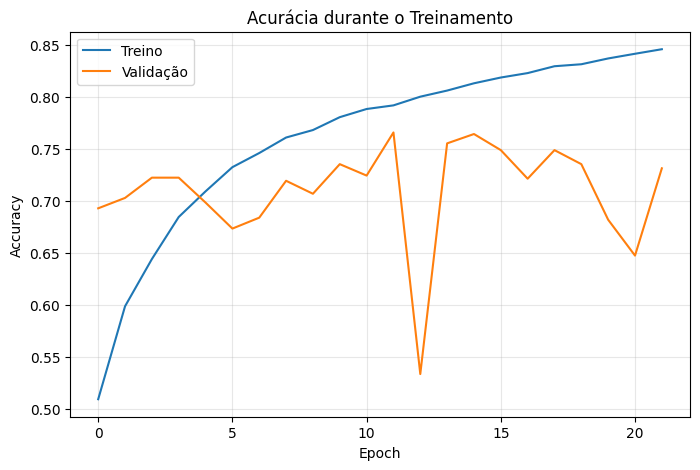

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

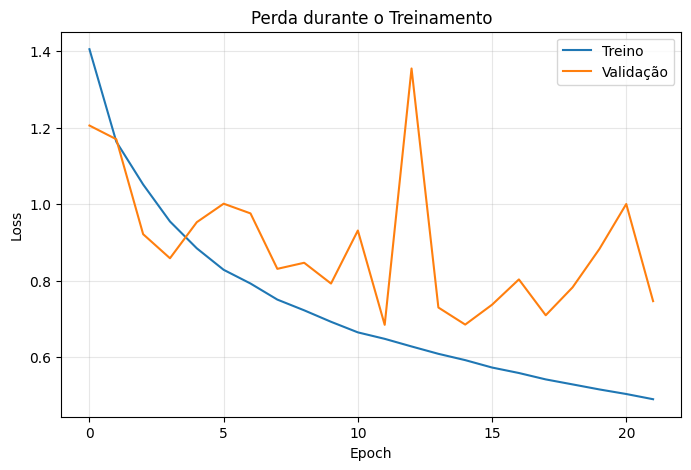

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])

In [31]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

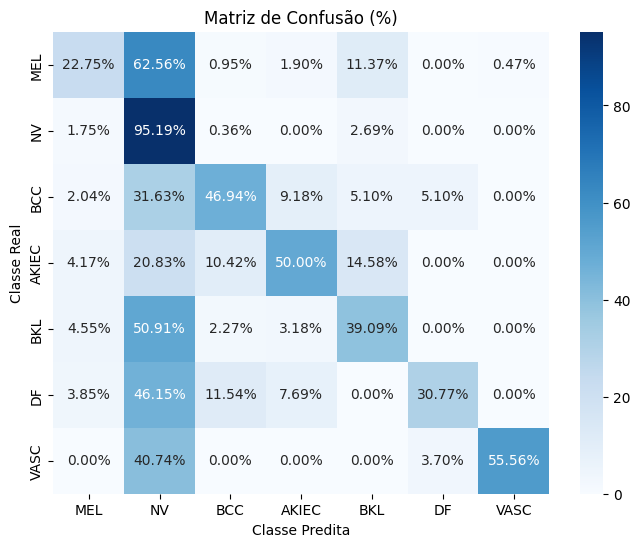

In [32]:
cm = confusion_matrix(y_true, y_pred)

cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
cm_labels = np.array([[f"{value:.2f}%" for value in row] for row in cm_percent])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_percent,
    annot=cm_labels,
    fmt="",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão (%)")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [33]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.5517    0.2275    0.3221       211
          NV     0.8093    0.9519    0.8748      1373
         BCC     0.6970    0.4694    0.5610        98
       AKIEC     0.5217    0.5000    0.5106        48
         BKL     0.5409    0.3909    0.4538       220
          DF     0.5714    0.3077    0.4000        26
        VASC     0.9375    0.5556    0.6977        27

    accuracy                         0.7659      2003
   macro avg     0.6614    0.4861    0.5457      2003
weighted avg     0.7389    0.7659    0.7377      2003



In [34]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7659

Macro Average:
  Precision: 0.6614
  Recall: 0.4861
  F1-Score: 0.5457

Weighted Average:
  Precision: 0.7389
  Recall: 0.7659
  F1-Score: 0.7377


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


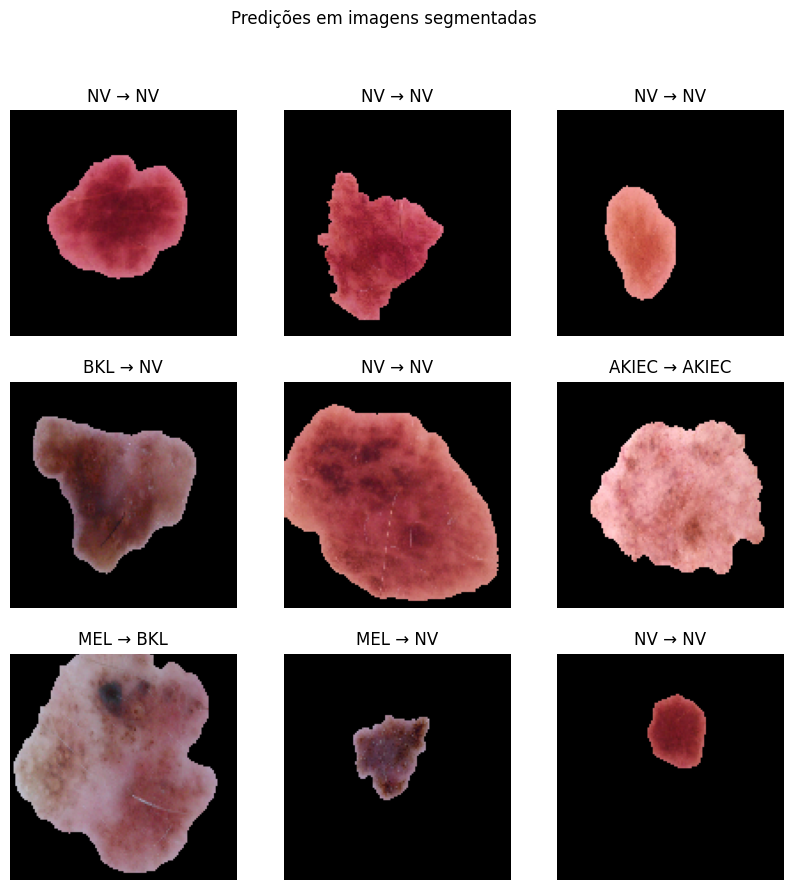

In [35]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.suptitle("Predições em imagens segmentadas")
plt.show()

In [36]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nDiagnóstico final:")
print(f"Train accuracy: {final_train_acc:.4f}")
print(f"Val accuracy: {final_val_acc:.4f}")
print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss: {final_val_loss:.4f}")


Diagnóstico final:
Train accuracy: 0.8458
Val accuracy: 0.7314
Train loss: 0.4894
Val loss: 0.7461
